## Early Stopping

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from keras.callbacks import EarlyStopping

In [2]:
x, y = make_circles(n_samples=200, noise=0.1, random_state=149)
x.shape

(200, 2)

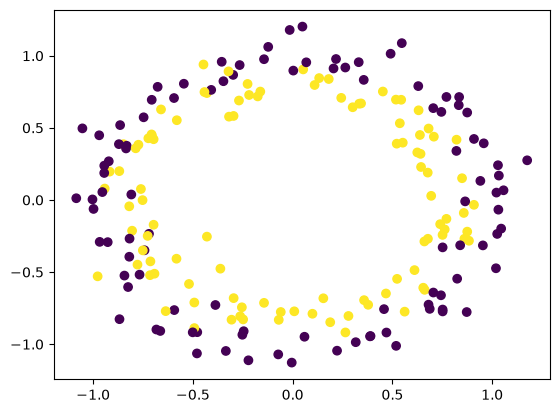

In [3]:
plt.scatter(x[:, 0], x[:, 1], c=y)
plt.show()

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=149)

In [5]:
model = Sequential()

model.add(Dense(4, input_dim=2, activation='relu'))
model.add(Dense(2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

D:\Deep Learning\dl\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 4)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │              10 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [7]:
history = model.fit(x, y, epochs=3000, validation_data=(x_test, y_test), verbose=0)

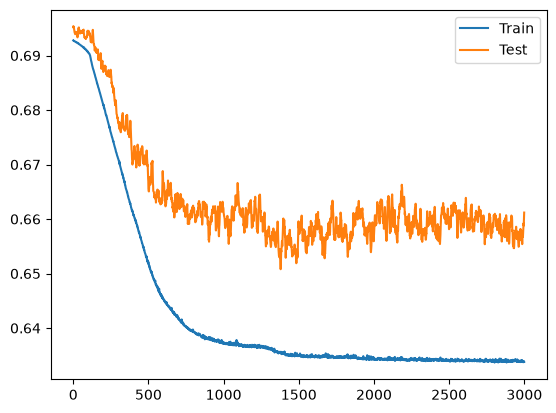

In [8]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.legend()
plt.show()

### Implementing Early Stopping Callback

In [12]:
call_back = EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001, # difference
    patience=30, # holds on and check
    verbose=1, # info
    mode='auto', # min, max, auto 
    baseline=None, # exact value to stop 
    restore_best_weights=True, # best weights
    start_from_epoch=25 # warm up period
)

model1 = Sequential()

model1.add(Dense(4, input_dim=2, activation='relu'))
model1.add(Dense(2, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

D:\Deep Learning\dl\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
history1 = model1.fit(x, y, epochs=3000, validation_data=(x_test, y_test), callbacks=call_back)

Epoch 1/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.4450 - loss: 0.6936 - val_accuracy: 0.4500 - val_loss: 0.6934
Epoch 2/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4300 - loss: 0.6934 - val_accuracy: 0.4500 - val_loss: 0.6934
Epoch 3/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5100 - loss: 0.6933 - val_accuracy: 0.3500 - val_loss: 0.6936
Epoch 4/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4200 - loss: 0.6933 - val_accuracy: 0.3750 - val_loss: 0.6938
Epoch 5/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.3750 - val_loss: 0.6939
Epoch 6/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.3750 - val_loss: 0.6939
Epoch 7/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.3750 - val_loss: 0.6940
Epoch 8/3000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.3750 - v

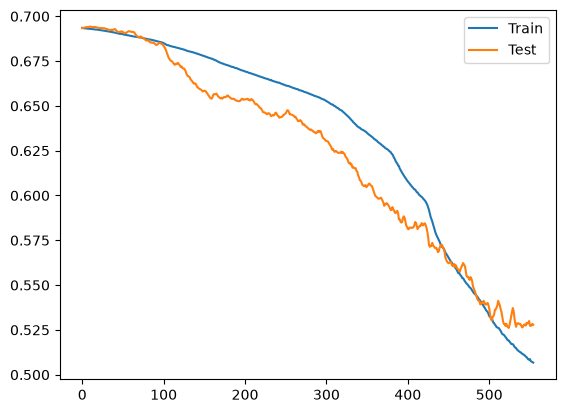

In [14]:
plt.plot(history1.history['loss'], label='Train')
plt.plot(history1.history['val_loss'], label='Test')

plt.legend()
plt.show()